In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,precision_score,f1_score,recall_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [5]:
!pip install pyarrow --upgrade

### Load Dataset

In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset
df = load_dataset("Hello-SimpleAI/HC3", "all")

README.md: 0.00B [00:00, ?B/s]

HC3.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found HC3.py

In [4]:
df.shape

(5000, 2)

In [5]:
df.dropna()

,text,label
0,Exercise plays a crucial role in supporting me...,1
1,Renewable energy helps fight climate change by...,1
2,"A futuristic smart city is a vibrant, intercon...",1
3,Healthy eating habits are especially important...,1
4,Machine learning is transforming healthcare by...,1
...,...,...
4995,Machine learning models can now detect cancer ...,1
4996,Blockchain can provide secure and transparent ...,1
4997,Volunteering at the animal shelter was a rewar...,0
4998,Machine learning models can now detect cancer ...,1


In [6]:
df.shape

(5000, 2)

In [7]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


In [9]:
df=df.sample(frac=1,random_state=42).reset_index(drop=True)

In [10]:
print(len(df[df['label']==0]))

2500


In [11]:
print(len(df[df['label']==1]))

2500


### Feature Extraction

In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
stop_words = set(stopwords.words('english'))

def lexical_features(text):
    words = word_tokenize(text.lower())
    words_only = [w for w in words if w.isalpha()]
    
    total_words = len(words_only)
    unique_words = len(set(words_only))
    
    # Type Token Ratio — how varied is the vocabulary?
    ttr = unique_words / total_words if total_words > 0 else 0
    
    # Average word length
    avg_word_len = sum(len(w) for w in words_only) / total_words if total_words > 0 else 0
    
    # How many filler/transition words AI loves to use
    ai_words = ["furthermore", "moreover", "additionally", "however", 
                "therefore", "consequently", "nevertheless", "thus"]
    ai_word_count = sum(1 for w in words_only if w in ai_words)
    ai_word_ratio = ai_word_count / total_words if total_words > 0 else 0
    
    return {
        "ttr":           ttr,
        "avg_word_len":  avg_word_len,
        "ai_word_ratio": ai_word_ratio,
        "total_words":   total_words
    }

# Test it
print(lexical_features("I went to the market today and honestly it was a mess."))

{'ttr': 1.0, 'avg_word_len': 3.5, 'ai_word_ratio': 0.0, 'total_words': 12}


In [16]:
def syntactic_features(text):
    sentences = sent_tokenize(text)
    num_sentences = len(sentences)
    
    if num_sentences == 0:
        return {"avg_sent_len": 0, "sent_len_variance": 0, "num_sentences": 0}
    
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    
    # Average sentence length
    avg_sent_len = sum(sent_lengths) / num_sentences
    
    # Variance — humans have HIGH variance, AI has LOW variance
    sent_len_variance = pd.Series(sent_lengths).var() if num_sentences > 1 else 0
    
    return {
        "avg_sent_len":      avg_sent_len,
        "sent_len_variance": sent_len_variance,
        "num_sentences":     num_sentences
    }

# Test it
print(syntactic_features("I went to market. It was crowded and noisy and I hated it. Fine."))

{'avg_sent_len': 5.666666666666667, 'sent_len_variance': 16.333333333333336, 'num_sentences': 3}


In [17]:
def stylometric_features(text):
    sentences = sent_tokenize(text)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    
    # Burstiness — key feature!
    # High burstiness = human (short + long sentences mixed)
    # Low burstiness  = AI   (all sentences similar length)
    if len(sent_lengths) > 1:
        mean = pd.Series(sent_lengths).mean()
        std  = pd.Series(sent_lengths).std()
        burstiness = std / mean if mean > 0 else 0
    else:
        burstiness = 0
    
    words = word_tokenize(text.lower())
    
    # Hedging words — humans use these casually
    hedge_words = ["maybe", "perhaps", "probably", "i think", 
                   "i guess", "kind of", "sort of", "not sure"]
    hedge_count = sum(1 for w in words if w in hedge_words)
    
    # Passive voice indicator words
    passive_words = ["was", "were", "been", "being", "is", "are"]
    passive_count = sum(1 for w in words if w in passive_words)
    passive_ratio = passive_count / len(words) if len(words) > 0 else 0
    
    return {
        "burstiness":    burstiness,
        "hedge_count":   hedge_count,
        "passive_ratio": passive_ratio
    }

# Test it
print(stylometric_features("Maybe I was wrong. I think it could have gone differently. Not sure though."))

{'burstiness': np.float64(0.36735282343519987), 'hedge_count': 1, 'passive_ratio': 0.058823529411764705}


In [18]:
def punctuation_features(text):
    total_chars = len(text)
    
    comma_ratio     = text.count(",")  / total_chars if total_chars > 0 else 0
    exclaim_ratio   = text.count("!")  / total_chars if total_chars > 0 else 0
    question_ratio  = text.count("?")  / total_chars if total_chars > 0 else 0
    ellipsis_count  = text.count("...")
    
    return {
        "comma_ratio":    comma_ratio,
        "exclaim_ratio":  exclaim_ratio,
        "question_ratio": question_ratio,
        "ellipsis_count": ellipsis_count
    }

# Test it
print(punctuation_features("Wait... really? That's amazing, wow!! I can't believe it."))

{'comma_ratio': 0.017543859649122806, 'exclaim_ratio': 0.03508771929824561, 'question_ratio': 0.017543859649122806, 'ellipsis_count': 1}


In [19]:
# This combines ALL features into one row
def extract_features(text):
    features = {}
    features.update(lexical_features(text))
    features.update(syntactic_features(text))
    features.update(stylometric_features(text))
    features.update(punctuation_features(text))
    return features

# Test on one text
print(extract_features("I went to the market today. It was okay I guess."))

{'ttr': 0.9090909090909091, 'avg_word_len': 3.272727272727273, 'ai_word_ratio': 0.0, 'total_words': 11, 'avg_sent_len': 6.5, 'sent_len_variance': 0.5, 'num_sentences': 2, 'burstiness': np.float64(0.10878565864408424), 'hedge_count': 0, 'passive_ratio': 0.07692307692307693, 'comma_ratio': 0.0, 'exclaim_ratio': 0.0, 'question_ratio': 0.0, 'ellipsis_count': 0}


In [20]:
print("Extracting features... please wait")

# Apply to every row in df
feature_df = df["text"].apply(extract_features)
feature_df = pd.DataFrame(feature_df.tolist())

print(f"Done! Feature matrix shape: {feature_df.shape}")
feature_df.head()

Extracting features... please wait
Done! Feature matrix shape: (5000, 14)


,ttr,avg_word_len,ai_word_ratio,total_words,avg_sent_len,sent_len_variance,num_sentences,burstiness,hedge_count,passive_ratio,comma_ratio,exclaim_ratio,question_ratio,ellipsis_count
0,1.0,7.428571,0.0,7,8.0,0.0,1,0.0,0,0.000000,0.0,0.0,0.0,0
1,1.0,5.181818,0.0,11,12.0,0.0,1,0.0,0,0.083333,0.0,0.0,0.0,0
2,1.0,5.888889,0.0,9,10.0,0.0,1,0.0,0,0.100000,0.0,0.0,0.0,0
3,1.0,4.800000,0.0,10,11.0,0.0,1,0.0,0,0.000000,0.0,0.0,0.0,0
4,1.0,7.000000,0.0,6,7.0,0.0,1,0.0,0,0.000000,0.0,0.0,0.0,0


In [21]:
df.head()

,text,label
0,Natural language processing powers modern voic...,1
1,The lecture on quantum mechanics was hard to f...,0
2,Volunteering at the animal shelter was a rewar...,0
3,She practices yoga every morning to stay focus...,0
4,Mindfulness practices reduce stress and anxiety.,1


In [25]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)


print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'\nTrain label split: {y_train.value_counts().to_dict()}')
print(f'Test label split : {y_test.value_counts().to_dict()}')

Training samples : 4000
Testing samples  : 1000

Train label split: {1: 2000, 0: 2000}
Test label split : {0: 500, 1: 500}


In [32]:

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),      # Unigrams + bigrams
        max_features=100000,     # Top 100k features
        sublinear_tf=True,       # Log scaling on term frequencies
        min_df=2,                # Ignore very rare terms
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w{2,}' # Words with 2+ characters only
    )),
    ('svm', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

print('Training model...')
pipeline.fit(X_train, y_train)
print('Training complete!')

Training model...
Training complete!


  Accuracy  : 99.90%
  Precision : 0.9980
  Recall    : 1.0000
  F1 Score  : 0.9990

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       500
AI-Generated       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



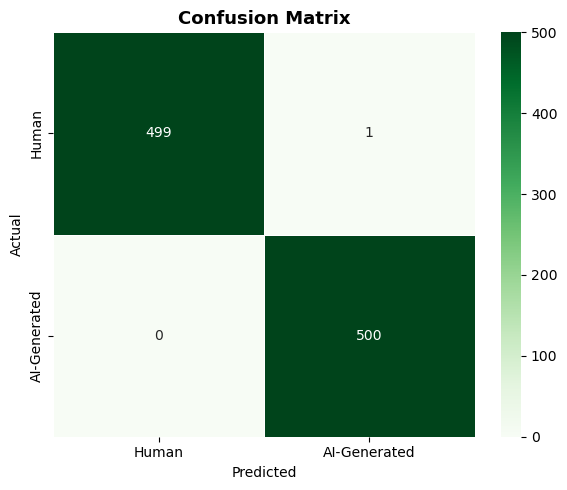

In [37]:
y_pred = pipeline.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 45)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred, target_names=['Human', 'AI-Generated']))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Human', 'AI-Generated'],
    yticklabels=['Human', 'AI-Generated'],
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [38]:
joblib.dump(pipeline, 'truetextai_model.pkl')
print('Model saved to truetextai_model.pkl')
print('Load it anytime with: pipeline = joblib.load("truetextai_model.pkl")')

Model saved to truetextai_model.pkl
Load it anytime with: pipeline = joblib.load("truetextai_model.pkl")
